# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data.csv')
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

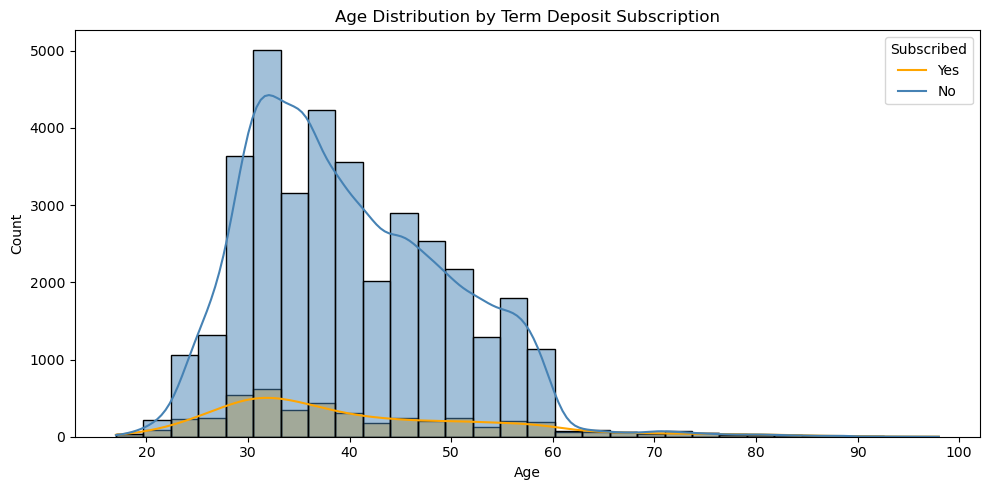

In [2]:
# Age distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, palette={'no': 'steelblue', 'yes': 'orange'})
plt.title('Age Distribution by Term Deposit Subscription')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Subscribed', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

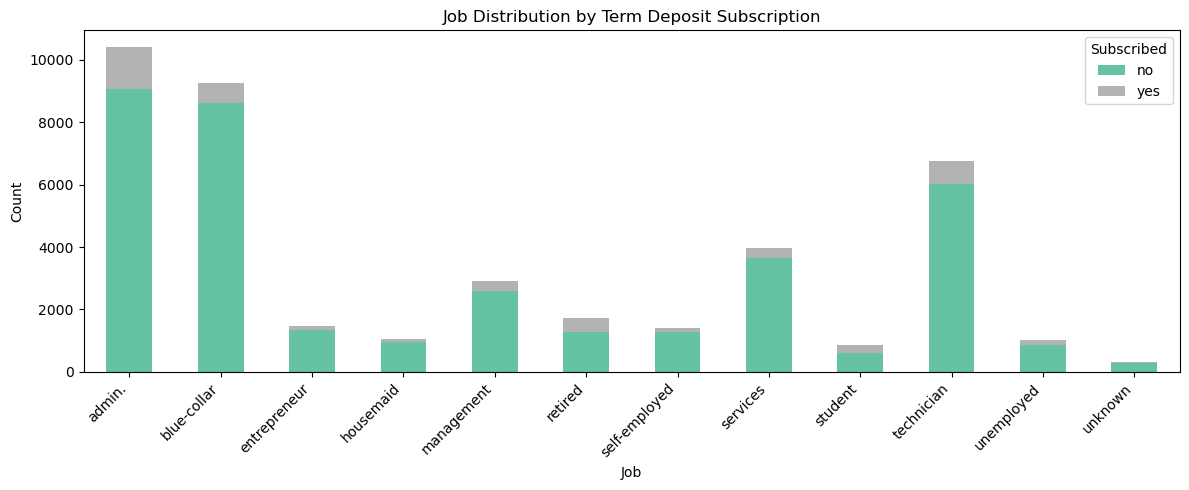

In [3]:
# Job distribution
job_counts = df.groupby(['job', 'y']).size().unstack()
job_counts.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 5))
plt.title('Job Distribution by Term Deposit Subscription')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

## Balance & Deposit Trends

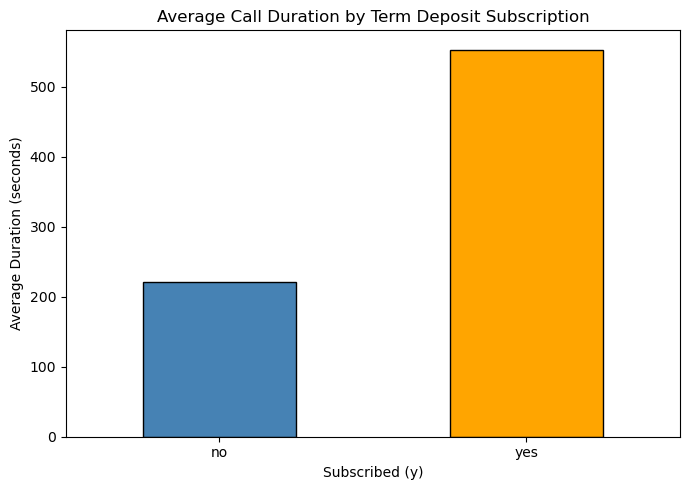

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


In [4]:
# Average balance by deposit subscription
# Using 'duration' as a proxy (no 'balance' column in this dataset)
avg_duration = df.groupby('y')['duration'].mean()
avg_duration.plot(kind='bar', color=['steelblue', 'orange'], edgecolor='black', figsize=(7, 5))
plt.title('Average Call Duration by Term Deposit Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(avg_duration)

## Campaign Effectiveness

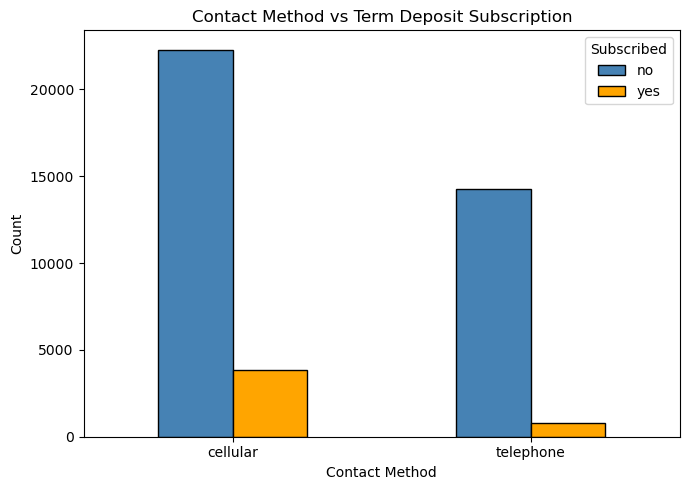

In [5]:
# Contact method analysis
contact_sub = df.groupby(['contact', 'y']).size().unstack()
contact_sub.plot(kind='bar', color=['steelblue', 'orange'], edgecolor='black', figsize=(7, 5))
plt.title('Contact Method vs Term Deposit Subscription')
plt.xlabel('Contact Method')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

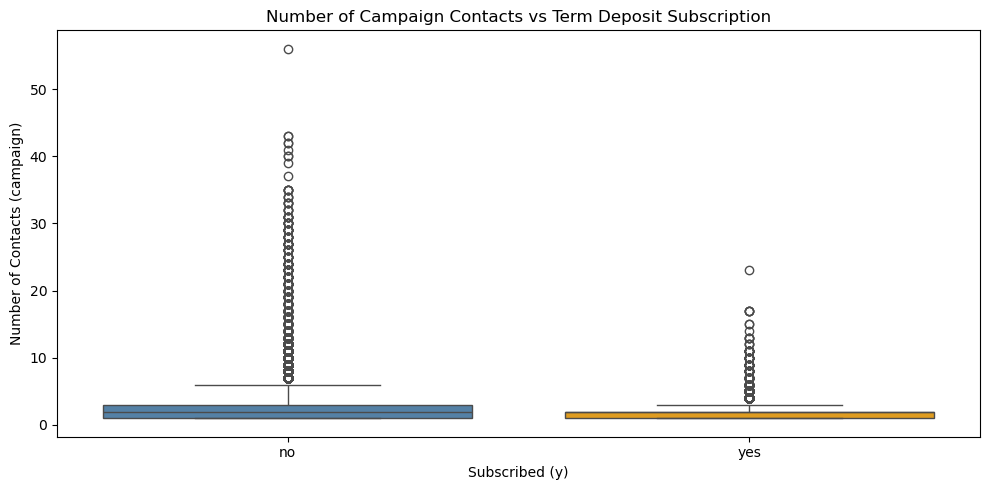

In [11]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, 
    x='y', 
    y='campaign', 
    hue='y', 
    palette={'no': 'steelblue', 'yes': 'orange'}, 
    legend=False
)
plt.title('Number of Campaign Contacts vs Term Deposit Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Number of Contacts (campaign)')
plt.tight_layout()
plt.show()

## Correlation Heatmap

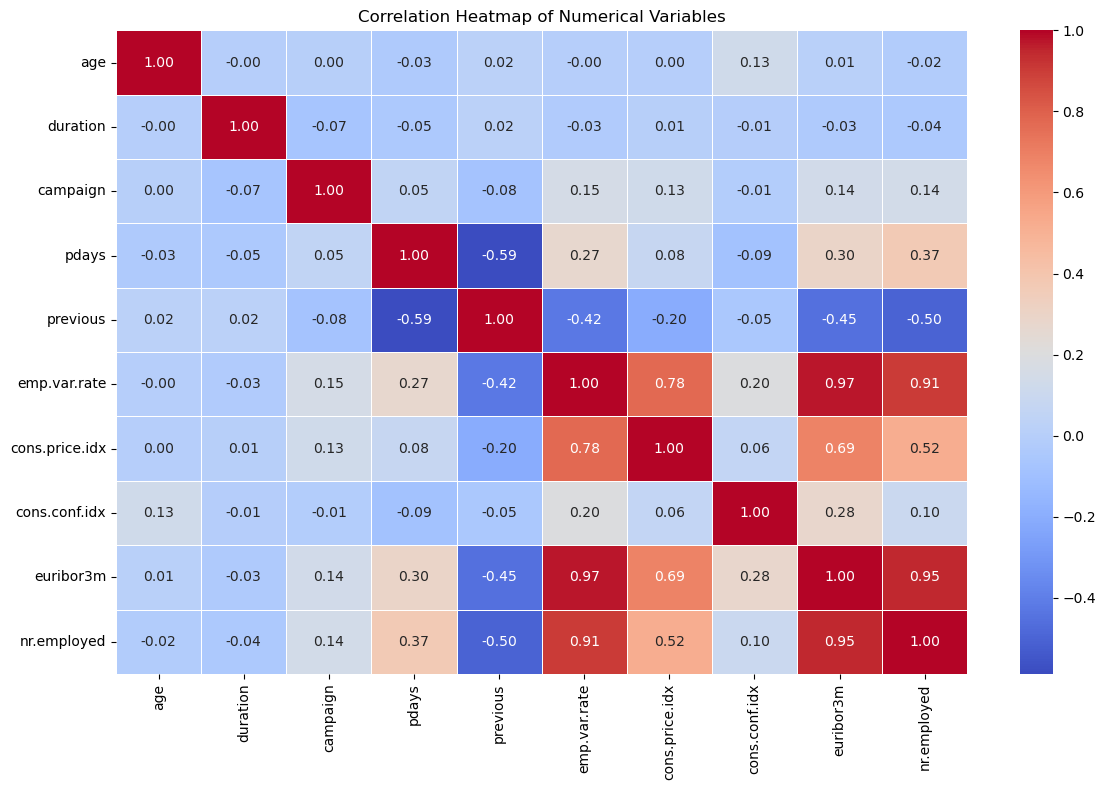

In [8]:
# Correlation of numerical variables
plt.figure(figsize=(12, 8))
num_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

## Predictive Modeling (Logistic Regression)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

# Encode categorical variables
df_model = df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['y'])
y = df_model['y']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



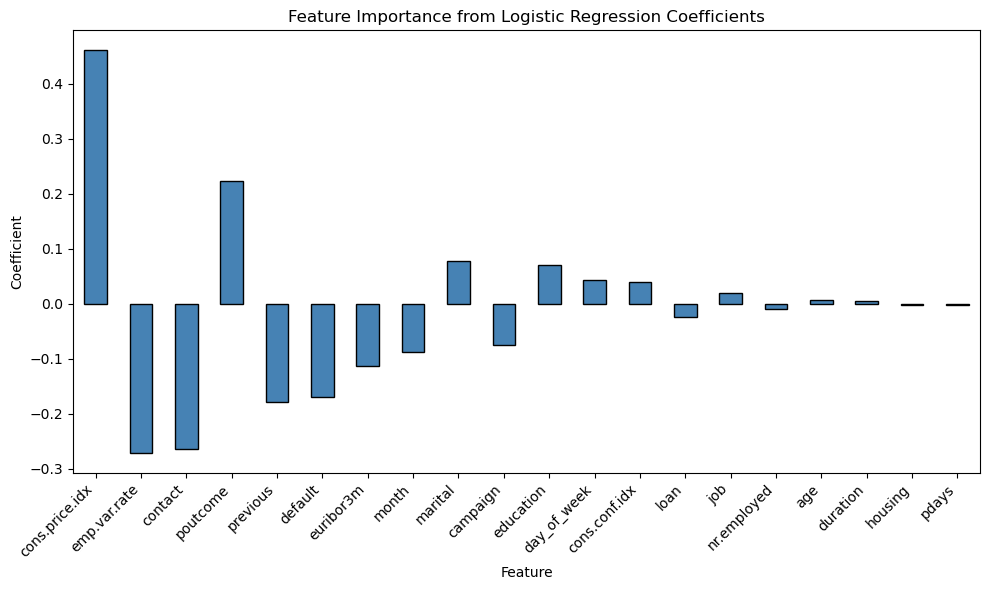

cons.price.idx    0.460977
emp.var.rate     -0.270235
contact          -0.264524
poutcome          0.224215
previous         -0.177870
default          -0.168325
euribor3m        -0.112394
month            -0.087160
marital           0.078445
campaign         -0.074821
education         0.070477
day_of_week       0.042667
cons.conf.idx     0.040724
loan             -0.023908
job               0.020592
nr.employed      -0.008544
age               0.006353
duration          0.004523
housing          -0.001645
pdays            -0.001424
dtype: float64


In [10]:
# Feature importance
feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance from Logistic Regression Coefficients')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(feature_importance)

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.